# Simulate Treatments on the GSC model

We will simulate RT using the LQ model. 
Differentation is according to Bachman and Hillen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import gsc_model_functions as gmf

In [2]:
def LQ_model(alpha, beta, d, factor=1):
    return np.exp(-factor*(alpha*d + beta*d*d))

In [3]:
doses = np.linspace(0,10, 101)

# Example RT parameters (for non stem cells)
alpha = 0.03
beta = 0.003

survival_fractions_PCs = LQ_model(alpha, beta, doses)
survival_fractions_GSCs = LQ_model(alpha, beta, doses, factor=0.13)
survival_fractions_TDCs = LQ_model(alpha, beta, doses, factor=0.5)
surv_test = LQ_model(alpha, 0, doses) # previous models e.g. Bachmann and Hillen 2013 cinsudered differnce between CSCs and non-CSCs is that beta = 0

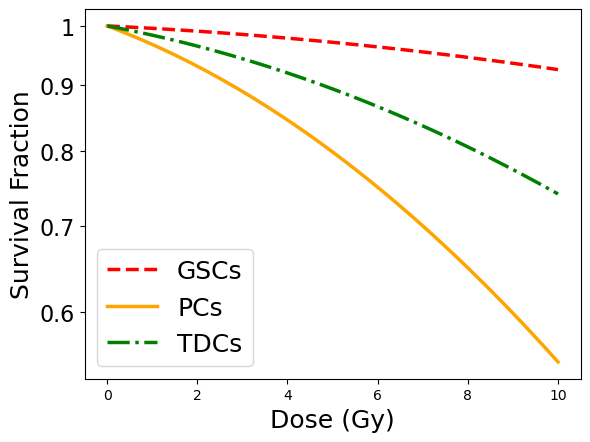

In [4]:
fig, ax = plt.subplots()

ax.semilogy(doses, survival_fractions_GSCs, color = 'red', linestyle = '--', label = "GSCs", linewidth=2.5)
ax.semilogy(doses, survival_fractions_PCs, color = 'orange', label = "PCs", linewidth=2.5)
ax.semilogy(doses, survival_fractions_TDCs, color = 'green', linestyle = '-.', label = "TDCs", linewidth=2.5)


ax.set_xlabel('Dose (Gy)', fontsize = 18)
ax.set_ylabel('Survival Fraction', fontsize = 18)
ax.legend(fontsize = 18)

ax.set_yticks([1, 0.9,0.8,0.7,0.6])
ax.set_yticklabels(['1', '0.9', '0.8', '0.7', '0.6'], fontsize = 16)

plt.savefig('Figs/LQ_model_plot.pdf', bbox_inches='tight')
plt.show()

In [5]:
def diff_fun(P_min, P_max, psi, B):
    return P_min + (P_max - P_min) * (1 / (1 + psi*B ) )

In [6]:
P_min = 0
p_max = 1

psi_vals = np.linspace(0.0001, 0.2, 101)
B_vals = np.array([20,50,100,200])

y_B = np.zeros((len(psi_vals), len(B_vals)))

for i in range(len(B_vals)):
    y_B[:,i] = diff_fun(P_min, p_max, psi_vals, B_vals[i])


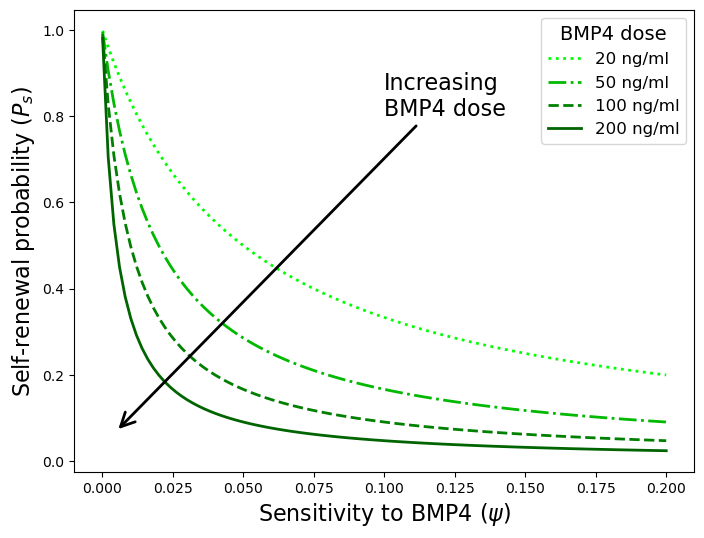

In [7]:


lin_style = [':','-.','--','-']
cols = [(0/255, 255/255, 0/255),  
     (0/255, 185/255, 0/255),
       'green'  ,     
    (0/255, 100/255, 0/255) ,
      ]

fig, ax = plt.subplots(figsize=(8,6))
for i in range(len(B_vals)):
    ax.plot(psi_vals, y_B[:,i], color = cols[i], linestyle = lin_style[i], label = f'{B_vals[i]} ng/ml', linewidth=2)

#plt.legend(fontsize = 12)
plt.xlabel('Sensitivity to BMP4 ($\\psi$)', fontsize = 16)
plt.ylabel('Self-renewal probability ($P_s$)', fontsize = 16)

plt.annotate('Increasing\nBMP4 dose', xy=(0.005, 0.07), xytext=(0.1, 0.8),
             arrowprops=dict(facecolor='black', arrowstyle='->', linewidth=2, mutation_scale=25), fontsize = 16)

plt.legend(title = 'BMP4 dose', fontsize = 12, title_fontsize = 14, loc = 'upper right')

plt.savefig('Figs/Ps_psi.pdf', bbox_inches='tight')
plt.show()

In [8]:
def simulate_RT(t_final,t_rad,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r, dose = 2, alpha=0.3, beta=0.03, eta = 0.13, mu = 0.5):
    t = np.arange(0, t_final+dt, dt)
    u = np.zeros((len(t), n+1))
    u[0] = u0
    for i in range(len(t)-1):
        u[i+1,:] = u[i,:] + dt * gmf.gsc_model_dudt(u[i,:], n, Ps, k, ms, mv, delta_s, delta_v,r)

        if t[i] in t_rad:
            u[i+1,:] = gmf.radiation(u[i,:],alpha,beta,eta,mu,dose,n)

    return t,u

def simulate_diff(t_final,t_BMP4_start,t_BMP4_end,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r, dose = 2, psi = 0):

    t = np.arange(0, t_final+dt, dt)
    u = np.zeros((len(t), n+1))
    u[0] = u0

    P_min = 0
    p_max = Ps
    BMP4 = 100 # Constant BMP4 delivery

    for i in range(len(t)-1):
        if t[i] > t_BMP4_start and t[i] <= t_BMP4_end:
            Ps = diff_fun(P_min, p_max, psi, BMP4)
        else:
            Ps = p_max

        u[i+1,:] = u[i,:] + dt * gmf.gsc_model_dudt(u[i,:], n, Ps, k, ms, mv, delta_s, delta_v,r)

    return t,u

def simulate_both(t_final,t_rad,t_BMP4_start,t_BMP4_end,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r, dose = 2, alpha=0.3, beta=0.03, eta = 0.13, mu = 0.5, psi = 0):
    t = np.arange(0, t_final+dt, dt)
    u = np.zeros((len(t), n+1))
    u[0] = u0

    BMP4 = 100 # Constant BMP4 delivery
    P_min = 0
    p_max = Ps

    for i in range(len(t)-1):

        if t[i] > t_BMP4_start and t[i] <= t_BMP4_end:
            Ps = diff_fun(P_min, p_max, psi, BMP4)

        u[i+1,:] = u[i,:] + dt * gmf.gsc_model_dudt(u[i,:], n, Ps, k, ms, mv, delta_s, delta_v,r)

        if t[i] in t_rad:
            u[i+1,:] = gmf.radiation(u[i,:],alpha,beta,eta,mu,dose,n)

    return t,u

In [9]:
def plot_fractions(t,u,ax):
    total = np.sum(u, axis=1)
    GSC_frac = u[:,0]/total
    PC_frac = np.sum(u[:,1:-1], axis=1)/total
    TDC_frac = u[:,-1]/total
    
    ax.plot(t,GSC_frac, color = 'red', linestyle = '--', label = "CSCs", linewidth=2.5)
    ax.plot(t,PC_frac, color = 'orange', label = "PCs", linewidth=2.5)
    ax.plot(t,TDC_frac, color = 'green', linestyle = '-.', label = "TDCs", linewidth=2.5)

In [10]:
def rad_times(t_start):
    # RT schedule is 5 days on with two days off for 6 weeks (30 fractions over 42 days)
    x = np.zeros(30)
    x[0] = t_start
    for i in range(1,len(x)):
        if i % 5 !=0:
            x[i] = x[i-1]  + 1
        else:
            x[i] = x[i-1]  + 3
    return x

In [11]:
# params for model simulation
dt = 0.1
t_end = 300
n = 10 
r = np.zeros(n)
r[0] = 1
Ps = 0.6
k = 1
ms = 0.05
mv = np.ones(n)*0.05
mv[-1] = 0
delta_s = 0.0005
delta_v = np.ones(n)*0.01



IC = 0.01


u0 = np.zeros(n+1)
u0[0] = IC


t_rad = rad_times(100)
t_BMP4_start = t_rad[0]
t_BMP4_end = t_rad[-1]

# BMP4 sensitvity
psi = 0.1

# RT sensitviety
alpha = 0.09
beta = 0.009


t, u = gmf.simulate_simple(t_end,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r)

t,u_RT = simulate_RT(t_end,t_rad,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r, alpha = alpha, beta=beta)

t, u_BMP4 = simulate_diff(t_end,t_BMP4_start,t_BMP4_end,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r, psi = psi)

t, u_both = simulate_both(t_end,t_rad,t_BMP4_start,t_BMP4_end,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r, alpha = alpha, beta=beta, psi = psi)


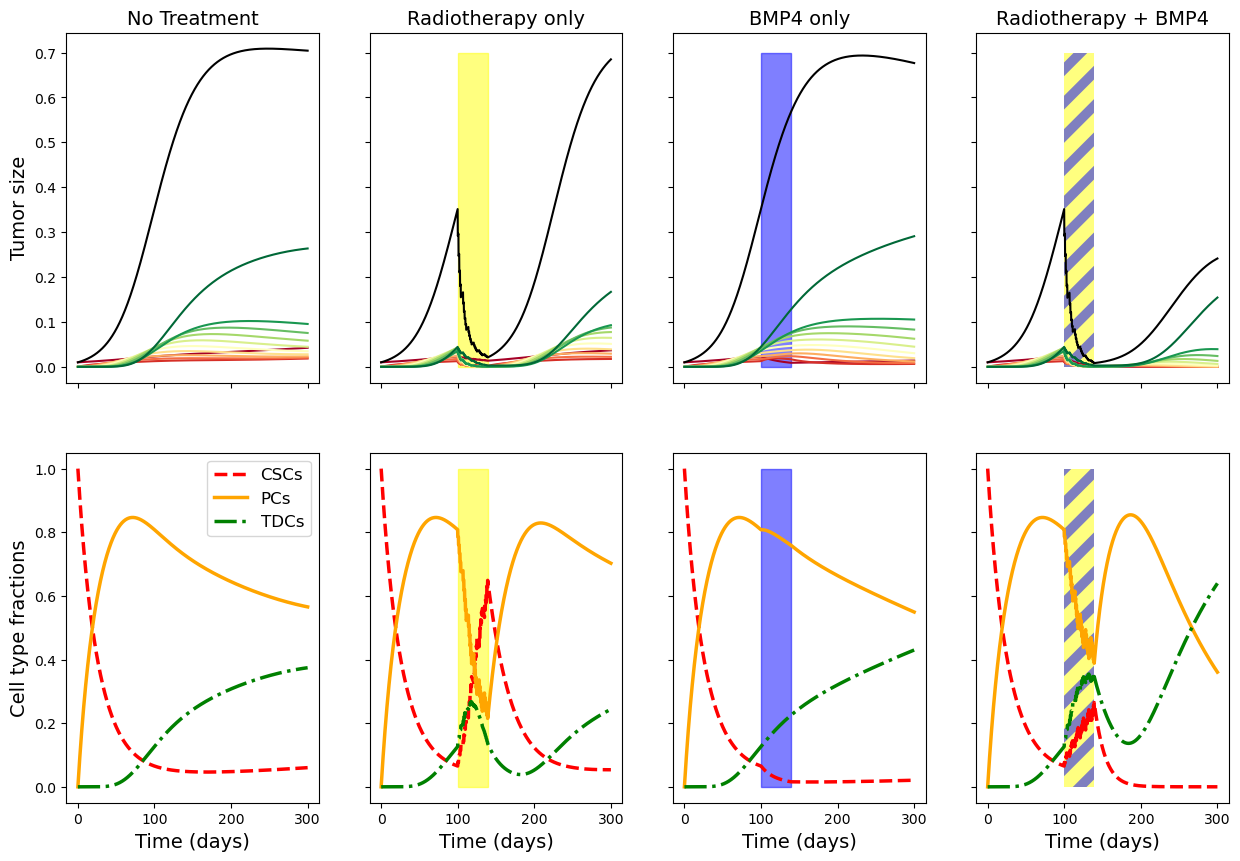

In [12]:
fig, ax = plt.subplots(2,4, figsize=(15,10), sharex = True, sharey = 'row')

# add rectangles to show treatment times
rect1 = matplotlib.patches.Rectangle((t_rad[0],0), t_rad[-1] - t_rad[0], 0.7, color='yellow', alpha = 0.5)
rect1_ = matplotlib.patches.Rectangle((t_rad[0],0), t_rad[-1] - t_rad[0], 1, color='yellow', alpha = 0.5)
ax[0,1].add_patch(rect1)
ax[1,1].add_patch(rect1_)

rect2 = matplotlib.patches.Rectangle((t_rad[0],0), t_rad[-1] - t_rad[0], 0.7, color='blue', alpha = 0.5)
rect2_ = matplotlib.patches.Rectangle((t_rad[0],0), t_rad[-1] - t_rad[0], 1, color='blue', alpha = 0.5)
ax[0,2].add_patch(rect2)
ax[1,2].add_patch(rect2_)

plt.rcParams['hatch.linewidth'] = 7
rect = matplotlib.patches.Rectangle( (t_rad[0],0), t_rad[-1] - t_rad[0], 0.7, facecolor='yellow', edgecolor='blue',hatch='/', linewidth=0, alpha = 0.5)
rect_ = matplotlib.patches.Rectangle( (t_rad[0],0), t_rad[-1] - t_rad[0], 1, facecolor='yellow', edgecolor='blue',hatch='/', linewidth=0, alpha = 0.5)
ax[0,3].add_patch(rect)
ax[1,3].add_patch(rect_)

# top row plot total tumour evolution
gmf.plot_all_compartments(t, u, ax[0,0])
gmf.plot_all_compartments(t, u_RT, ax[0,1])
gmf.plot_all_compartments(t, u_BMP4, ax[0,2])
gmf.plot_all_compartments(t, u_both, ax[0,3])



# bottom row plot the fractions of each cell type
plot_fractions(t,u,ax[1,0])
plot_fractions(t,u_RT,ax[1,1])
plot_fractions(t,u_BMP4,ax[1,2])
plot_fractions(t,u_both,ax[1,3])

ax[0,0].set_title('No Treatment', fontsize = 14)
ax[0,1].set_title('Radiotherapy only', fontsize = 14)
ax[0,2].set_title('BMP4 only', fontsize = 14)
ax[0,3].set_title('Radiotherapy + BMP4', fontsize = 14)

ax[0,0].set_ylabel('Tumor size', fontsize = 14)
ax[1,0].set_ylabel('Cell type fractions', fontsize = 14)

for i in range(4):
    ax[1,i].set_xlabel('Time (days)', fontsize = 14)
    
ax[1,0].legend(fontsize = 12)

plt.savefig('Figs/Treatment_effects.pdf', bbox_inches='tight')
plt.show()